In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
data_dir = '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620'
fn_list = glob.glob(os.path.join(data_dir, 'zbest-*.fits'))

In [4]:
fn_list

['/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-6-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-2-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-9-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-3-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-1-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-0-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-5-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-7-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-8-80620.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80620/zbest-4-80620.fits']

In [5]:
zbest = []
for fn in fn_list:
    tmp1 = Table.read(fn, hdu='ZBEST')
    tmp2 = Table.read(fn, hdu='FIBERMAP')
    tmp = join(tmp1, tmp2, keys='TARGETID', metadata_conflicts='silent')
    zbest.append(tmp)
zbest = vstack(zbest)
print(len(zbest))

5000


In [6]:
zbest[:5]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKID,BRICK_OBJID,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,BRICKNAME,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39633442891104409,13570.51065993309,252.13164056701 .. 0.886506089625296,0.527975040374616,4.2242766947463335e-05,0,7740,GALAXY,,10,3018.566310092807,0,0,6,0,6000,3416,0,144.13891993818933,65.11402931706995,0.0,0.0,2020.9651,5400.0,1152921504610779257,1,TGT,-14.290018,27.68363,3200,0.3528483554192742,7,9011,630803,153,DEV,1.7464677,8.459082,24.907116,228.85945,77.28218,39.598522,0,,0.0,0.0,0.0,0.0,1444p650,0.049185436,53.153896,34.087177,0.6846764,3.3162556,9.764461,0.6846764,3.3162556,9.764461,0,4.0,0.86969185,-0.1107076,0.11158028,N,3200,1,1152921504610779257,257,0,0,0,0,2,-14.287,27.675,-0.0008,-0.0024000000000000002,0.0,0.0,5,0.004516635916254486,0.004939635614091388,3416,3416,1
39633442891104732,12532.511898741126,3.292843714637784 .. -2.816966632107718,0.7540477944662903,8.19802773515428e-05,4,7754,GALAXY,,10,7.318344481289387,0,0,6,2,6002,3449,0,144.20262729246537,65.115167985979,0.0,0.0,2020.9651,5400.0,70369549550342,1,TGT,-20.806385,27.960236,3400,0.9918990128622347,3,9011,630803,476,PSF,0.30172542,0.3735413,0.5162319,520.5304,224.82082,199.19801,0,,0.0,0.0,0.0,0.0,1444p650,0.05047323,1.2604897,2.0518255,0.23493911,0.2908587,0.401965,0.23493911,0.2908587,0.401965,0,0.0,0.0,0.0,0.0,N,3400,1,70369549550342,0,0,0,0,0,2,-20.801,27.952,-0.0014,-0.0027999999999999995,0.0,0.0,5,0.0046260134024881504,0.00596657355607052,3449,3449,1
39633445445437803,12943.045487552881,99.16896424689408 .. 0.2566206478266105,0.9175010261352138,6.093645873830991e-05,0,7757,GALAXY,,10,743.992464452982,0,0,6,1,6001,3406,0,144.17137932160966,65.14266095135218,0.0,0.0,2020.9651,5400.0,3932281,1,TGT,-17.614204,34.644962,3200,0.7378795120281445,1,9011,631412,2411,REX,0.20990504,0.8991048,5.402444,449.207,175.06076,71.30998,0,,0.0,0.0,0.0,0.0,1440p652,0.049400482,23.078142,16.121601,0.13412279,0.57449996,3.4519932,0.13412279,0.57449996,3.4519932,0,1.0,0.31690168,0.0,0.0,N,3200,1,3932281,0,0,0,0,0,2,-17.608,34.628,-0.0004,-0.0019999999999999996,0.0,0.0,5,0.002683281572999748,0.005138093031466052,3406,3406,1
39633445445437887,34298.499831199646,0.004643028588514845 .. 0.0,0.8167809981243788,1.5772348881949044e-05,0,7751,QSO,,4,25628.058599472046,0,0,6,3,6003,3420,0,144.1853113162898,65.19187923539573,0.10880273,-0.9102083,2020.9651,5400.0,2305856203355861077,1,TGT,-19.044033,46.6207,3400,0.06142028881416206,7,9011,631412,2495,PSF,19.241678,21.597849,26.032757,186.69556,103.16584,74.88964,1064931849644007040,G2,19.283226,19.303802,18.705069,0.36553743,1440p652,0.05131581,112.89831,126.23834,14.9632

In [7]:
# SV1 target bits
bitvalues = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 53, 54, 55, 56, 57, 32, 33, 34, 35, 36, 37, 49, 50, 51, 52, 60, 61, 62]
bitnames = ['LRG', 'ELG', 'QSO', 'LRG_OPT', 'LRG_IR', 'LRG_SV_OPT', 'LRG_SV_IR', 'LOWZ_FILLER', 'ELG_SV_GTOT', 'ELG_SV_GFIB', 'ELG_FDR_GTOT', 'ELG_FDR_GFIB', 'QSO_COLOR_4PASS', 'QSO_RF_4PASS', 'QSO_COLOR_8PASS', 'QSO_RF_8PASS', 'QSO_HZ_F', 'QSO_Z5', 'LRG_OPT_NORTH', 'LRG_IR_NORTH', 'LRG_SV_OPT_NORTH', 'LRG_SV_IR_NORTH', 'LOWZ_FILLER_NORTH', 'LRG_OPT_SOUTH', 'LRG_IR_SOUTH', 'LRG_SV_OPT_SOUTH', 'LRG_SV_IR_SOUTH', 'LOWZ_FILLER_SOUTH', 'ELG_SV_GTOT_NORTH', 'ELG_SV_GFIB_NORTH', 'ELG_FDR_GTOT_NORTH', 'ELG_FDR_GFIB_NORTH', 'ELG_SV_GTOT_SOUTH', 'ELG_SV_GFIB_SOUTH', 'ELG_FDR_GTOT_SOUTH', 'ELG_FDR_GFIB_SOUTH', 'QSO_COLOR_4PASS_NORTH', 'QSO_RF_4PASS_NORTH', 'QSO_COLOR_8PASS_NORTH', 'QSO_RF_8PASS_NORTH', 'QSO_HZ_F_NORTH', 'QSO_Z5_NORTH', 'QSO_COLOR_4PASS_SOUTH', 'QSO_RF_4PASS_SOUTH', 'QSO_COLOR_8PASS_SOUTH', 'QSO_RF_8PASS_SOUTH', 'QSO_HZ_F_SOUTH', 'QSO_Z5_SOUTH', 'SKY', 'STD_FAINT', 'STD_WD', 'STD_BRIGHT', 'BAD_SKY', 'SUPP_SKY', 'NO_TARGET', 'BRIGHT_OBJECT', 'IN_BRIGHT_OBJECT', 'NEAR_BRIGHT_OBJECT', 'BGS_ANY', 'MWS_ANY', 'SCND_ANY']

def bitmask_summary(mask_values, names, bits):
    mask_values = np.array(mask_values, dtype=np.uint64)
    t = Table()
    t['name'] = names
    t['bit'] = bits
    t['count'] = 0
    for index in range(len(bits)):
        bit = bits[index]
        t['count'][index] = np.sum(mask_values & (2**bit)>0)
    t['frac (%)'] = t['count']/len(mask_values)*100
    t['frac (%)'].format = "%.3f"
    return t

In [8]:
t = bitmask_summary(zbest['SV1_DESI_TARGET'], bitnames, bitvalues)
t.pprint(max_lines=-1)

         name         bit count frac (%)
--------------------- --- ----- --------
                  LRG   0  2049   40.980
                  ELG   1  1212   24.240
                  QSO   2  1682   33.640
              LRG_OPT   3   505   10.100
               LRG_IR   4   543   10.860
           LRG_SV_OPT   5  1436   28.720
            LRG_SV_IR   6  1832   36.640
          LOWZ_FILLER   7     0    0.000
          ELG_SV_GTOT   8  1026   20.520
          ELG_SV_GFIB   9  1092   21.840
         ELG_FDR_GTOT  10   538   10.760
         ELG_FDR_GFIB  11   608   12.160
      QSO_COLOR_4PASS  12   496    9.920
         QSO_RF_4PASS  13   899   17.980
      QSO_COLOR_8PASS  14   197    3.940
         QSO_RF_8PASS  15   333    6.660
             QSO_HZ_F  16   269    5.380
               QSO_Z5  17    72    1.440
        LRG_OPT_NORTH  18   505   10.100
         LRG_IR_NORTH  19   543   10.860
     LRG_SV_OPT_NORTH  20  1436   28.720
      LRG_SV_IR_NORTH  21  1832   36.640
    LOWZ_FILLER_

In [9]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = zbest['SV1_DESI_TARGET'] & 2**0>0
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

ts_sky = (zbest['DESI_TARGET'] & 2**32>0)
print(np.sum(ts_sky))

505
543
2049

1682
49
4
800


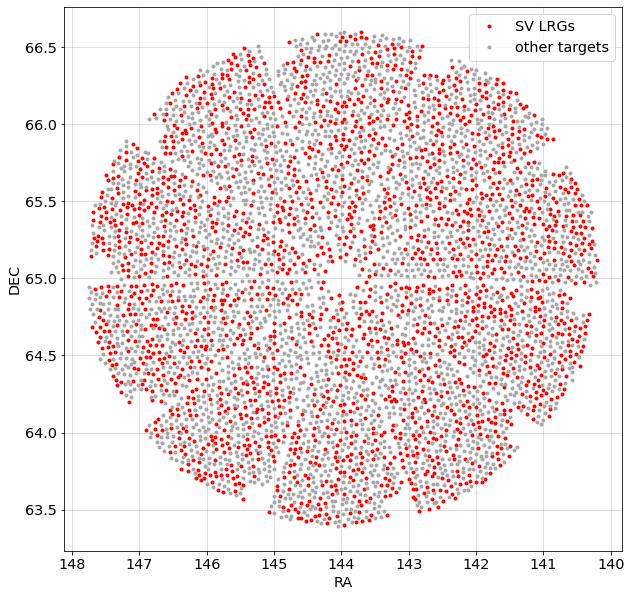

In [10]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [11]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']!=0
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[~mask]

# Remove "no data" fibers
nodata = zbest['ZWARN'] & 2**9>0
print(np.sum(nodata), np.sum(~nodata), np.sum(nodata)/len(nodata))
zbest = zbest[~nodata]

print(len(zbest))

883 4117 0.1766
0 4117 0.0
4117


In [12]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

421
443
1689

1388
35
4


In [13]:
mask_zwarn = zbest['ZWARN']==0
print(np.sum((~mask_zwarn) & lrg_opt), np.sum((~mask_zwarn) & lrg_opt)/np.sum(lrg_opt))
print(np.sum((~mask_zwarn) & lrg_ir), np.sum((~mask_zwarn) & lrg_ir)/np.sum(lrg_ir))
print(np.sum((~mask_zwarn) & lrg_sv), np.sum((~mask_zwarn) & lrg_sv)/np.sum(lrg_sv))

1 0.0023752969121140144
1 0.002257336343115124
11 0.006512729425695678


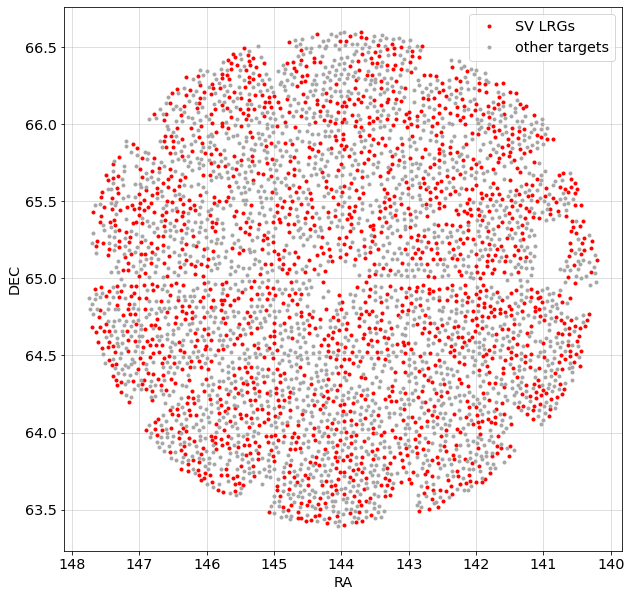

In [14]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

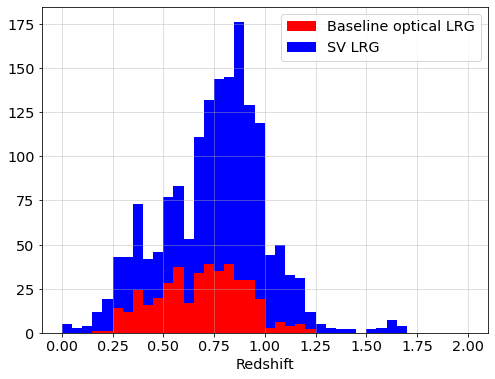

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

No ZWARN cut:


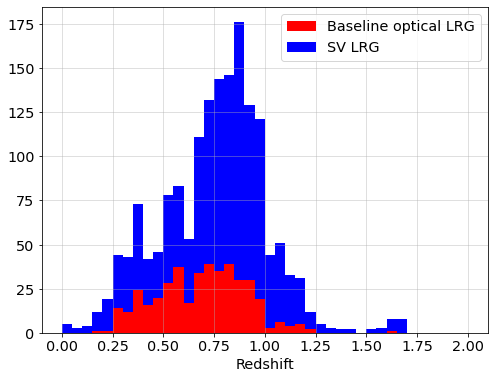

In [16]:
print('No ZWARN cut:')
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

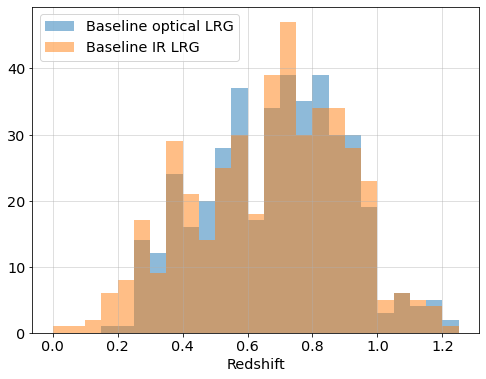

In [17]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline optical LRG'], alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline IR LRG'], alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

--------
# Stellar contamination

In [18]:
print('LRG_OPT:')
mask = lrg_opt & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,416,99.0
STAR,4,1.0


In [19]:
print('LRG_IR:')
mask = lrg_ir & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,425,96.2
QSO,11,2.5
STAR,6,1.4


In [20]:
print('LRG_SV:')
mask = lrg_sv & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,1630,97.1
QSO,25,1.5
STAR,23,1.4


In [21]:
mask_star = zbest['SPECTYPE']=='STAR'
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_qso = zbest['SPECTYPE']=='QSO'

In [22]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

23
9


In [23]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

4
2


In [24]:
mask = lrg_sv & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKID,BRICK_OBJID,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,BRICKNAME,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39633452999377202,11676.655539264273,-154.48039292822074 .. 0.0,-6.635423602989761e-05,2.4883281637624797e-05,0,7733,STAR,M,5,85.4726102153545,0,0,6,362,6362,3178,0,145.87939680982296,66.09782536351383,0.0,0.0,2020.9651,5400.0,3145825,1,TGT,-191.49414,277.16077,3200,0.15390767430283148,1,9011,633213,306,REX,0.08326559,0.6809371,6.8113484,1107.5615,264.98608,67.36384,0,,0.0,0.0,0.0,0.0,1461p660,0.091757596,23.204584,11.53253,0.051623806,0.42217398,4.2229657,0.051623806,0.42217398,4.2229657,16,1.0,0.34289292,0.0,0.0,N,3200,1,3145825,0,0,0,0,0,2,-191.405,277.023,-0.003,0.0010000000000000005,0.0,0.0,3,0.00823407554009556,0.004494441010848846,3178,3178,1
39633455457239519,10291.444471366185,-67.53778300384992 .. 0.0,0.00017528494858726917,3.86238897936582e-05,0,7720,STAR,M,5,44.15758275292501,0,0,6,223,6223,3461,0,144.93697012245696,66.14148009530459,0.0,0.0,2020.9651,5400.0,3145825,1,TGT,-95.18958,284.52988,3200,0.9344575346094202,1,9011,633799,479,PSF,0.07085117,0.38637653,2.623688,892.74927,280.56622,179.01645,0,,0.0,0.0,0.0,0.0,1451p662,0.17891228,11.001403,7.879777,0.055078685,0.3003636,2.0396175,0.05508527,0.30037972,2.0396504,0,0.0,0.0,0.0,0.0,N,3200,1,3145825,0,0,0,0,0,2,-95.15,284.419,-0.0034000000000000002,0.0024000000000000002,0.0,0.0,2,0.006587867636800242,0.007293833011524188,3461,3461,1
39633437673393400,14468.825892588842,-77.62615361698464 .. 0.0,-0.00034182761528826967,1.4542535345795994e-05,0,7740,STAR,M,5,552.4757337134597,0,0,2,450,2450,1214,0,140.74206081959903,64.50288494990433,0.0,0.0,2020.9651,5400.0,140737491632229,1,TGT,353.54822,-115.09569,3400,0.7164794031214294,1,9011,629559,3320,PSF,0.084712565,0.36893287,2.8954659,989.61383,486.23108,100.665405,0,,0.0,0.0,0.0,0.0,1404p645,0.060931496,8.907295,8.82019,0.06594979,0.28721887,2.2541564,0.06594979,0.28721887,2.2541564,0,0.0,0.0,0.0,0.0,N,3400,1,140737491632229,0,0,0,0,0,2,353.519,-115.037,0.001,0.001,0.0,0.0,9,0.00348010216963685,0.0069041050590693265,1214,1214,1
39633440299025971,14816.754146522078,-116.60594903162152 .. 0.0,-0.00032624582698677335,1.0654692322046526e-05,0,7757,STAR,M,5,2046.6172915639545,0,0,2,34,2034,1443,0,143.00755085476564,64.79342905249351,0.0,0.0,2020.9651,5400.0,1048609,1,TGT,103.205864,-49.250065,3200,0.12686313610415212,1,9011,630185,1587,PSF,0.19527414,1.1034268,5.170673,617.317,184.2982,101.59242,0,,0.0,0.0,0.0,0.0,1430p647,0.045741923,16.210817,13.126875,0.15207765,0.8593383,4.0268703,0.15229772,0.85966074,4.027456,0,0.0,0.0,0.0,0.0,N,3200,1,1048609,0,0,0,0,0,2,103.198,-

In [25]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [26]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2'])
    zbest['gmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_G'])/zbest['FLUX_G']
    zbest['rmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_R'])/zbest['FLUX_R']
    zbest['zmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_Z'])/zbest['FLUX_Z']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z'])

zbest['z_phot'] = zbest['Z']

416


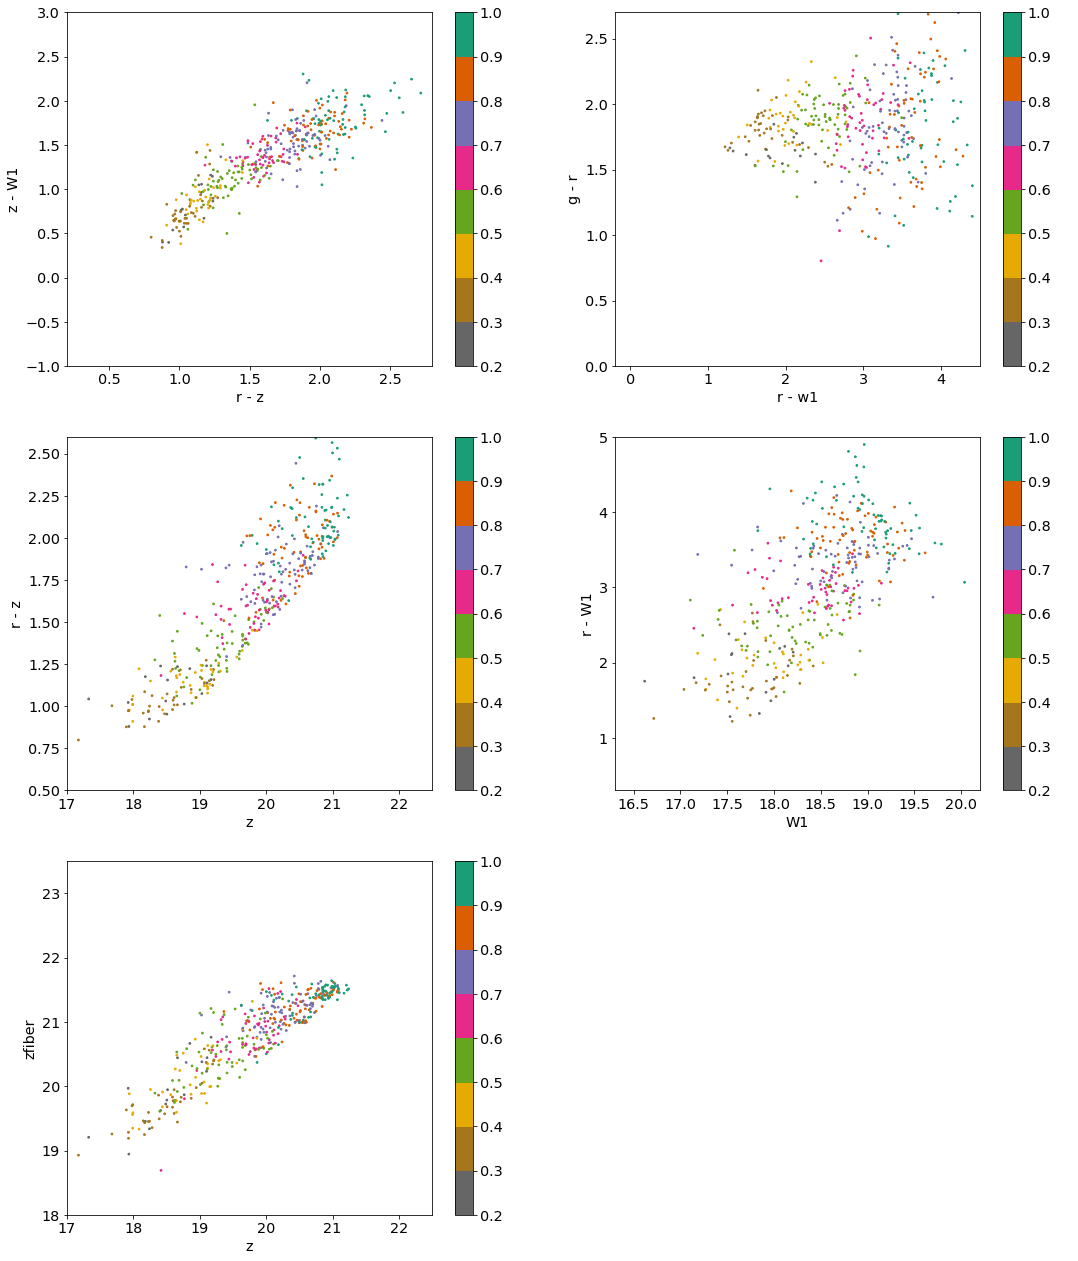

In [27]:
mask = lrg_opt & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

4


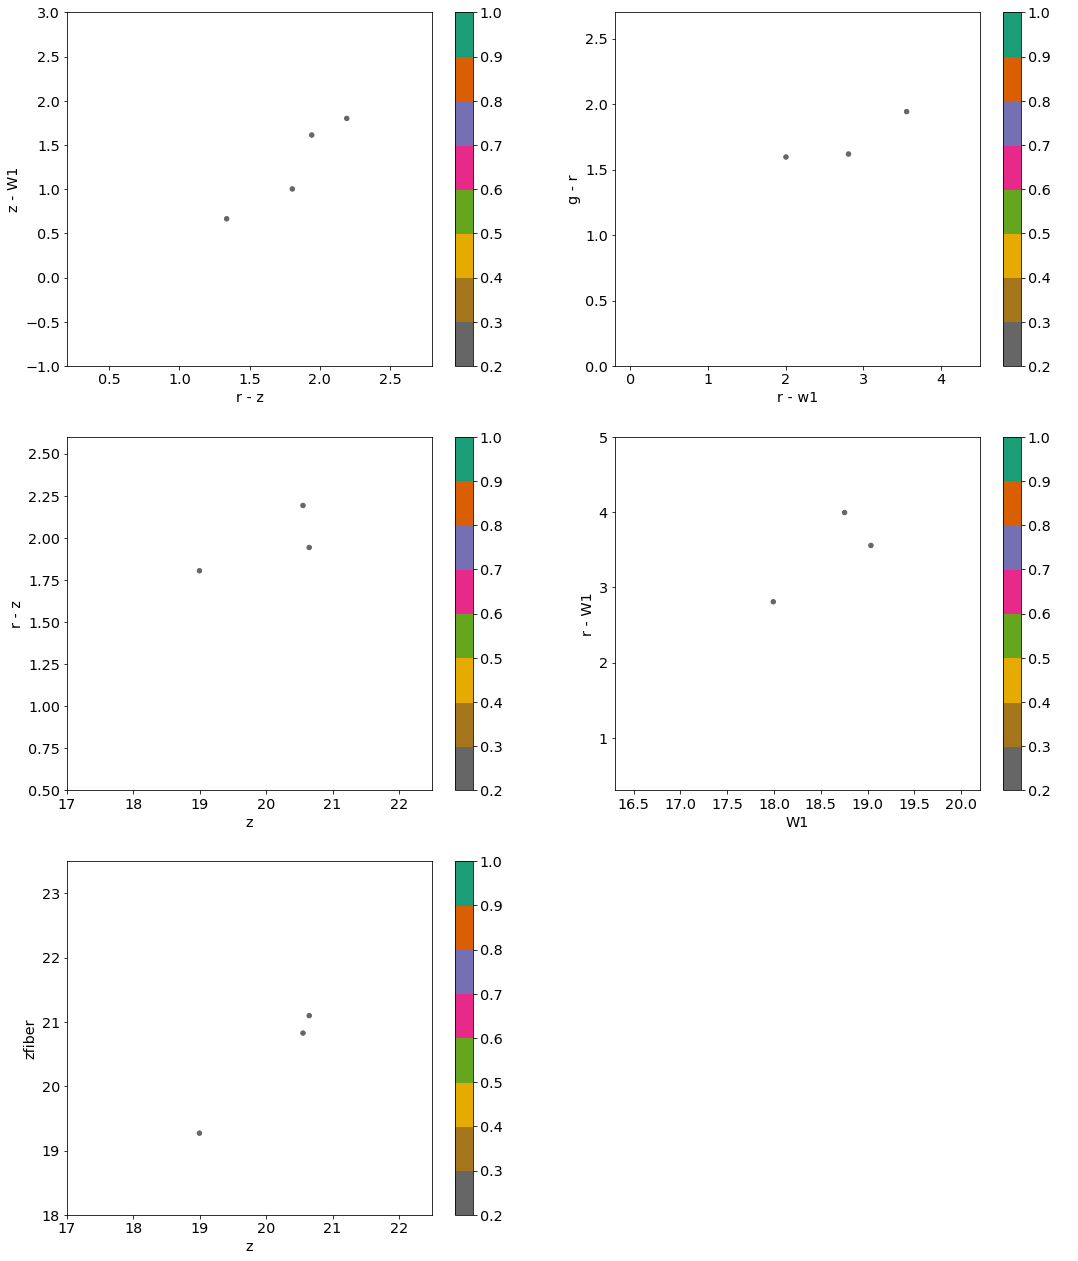

In [28]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

1655


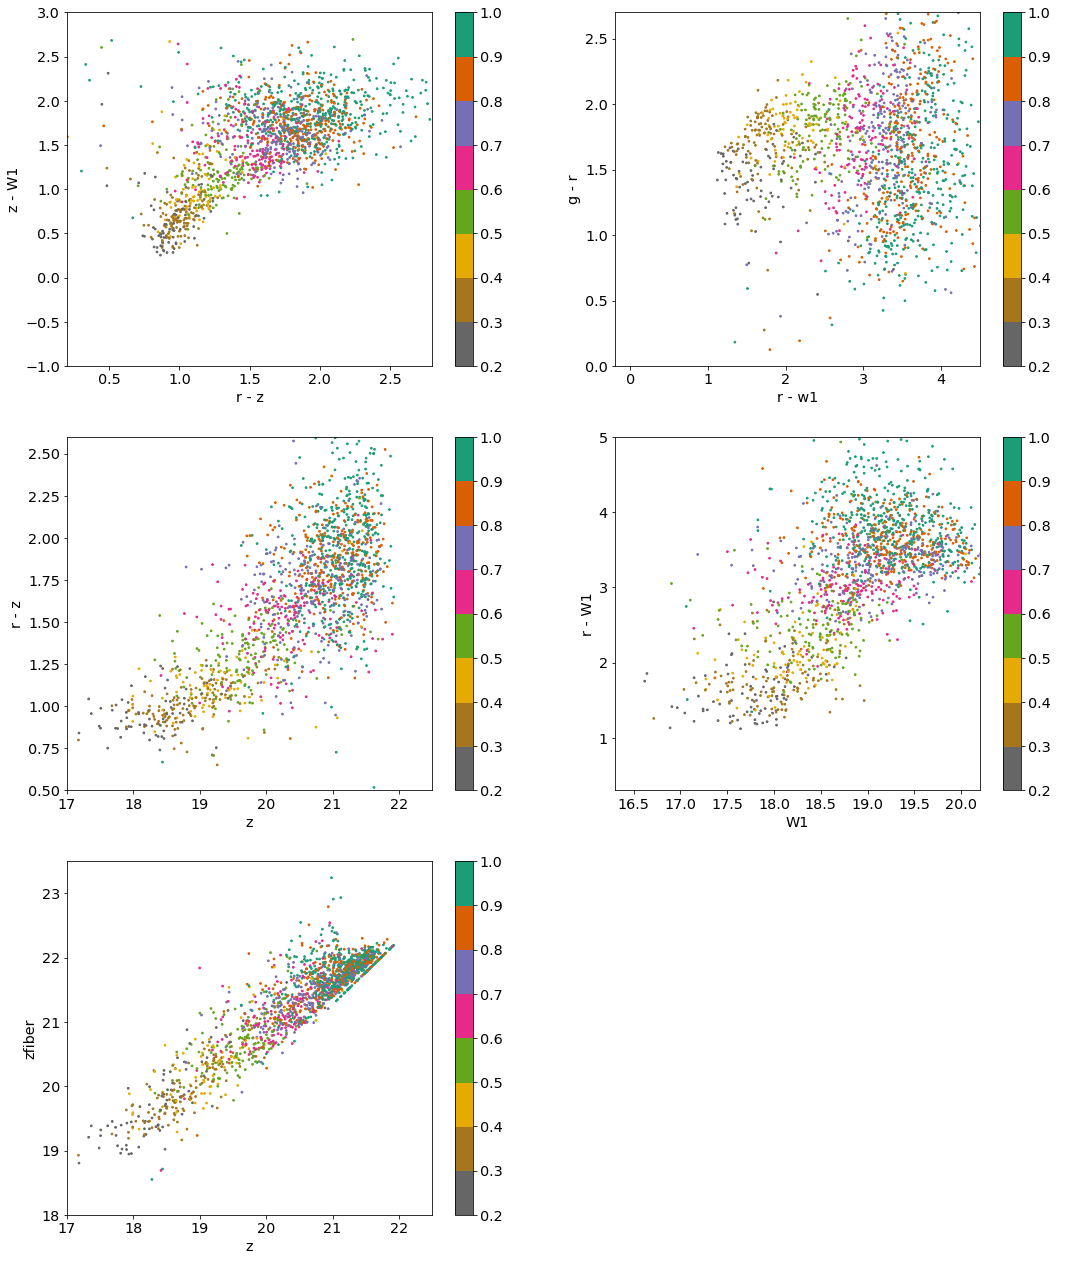

In [29]:
mask = lrg_sv & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

23


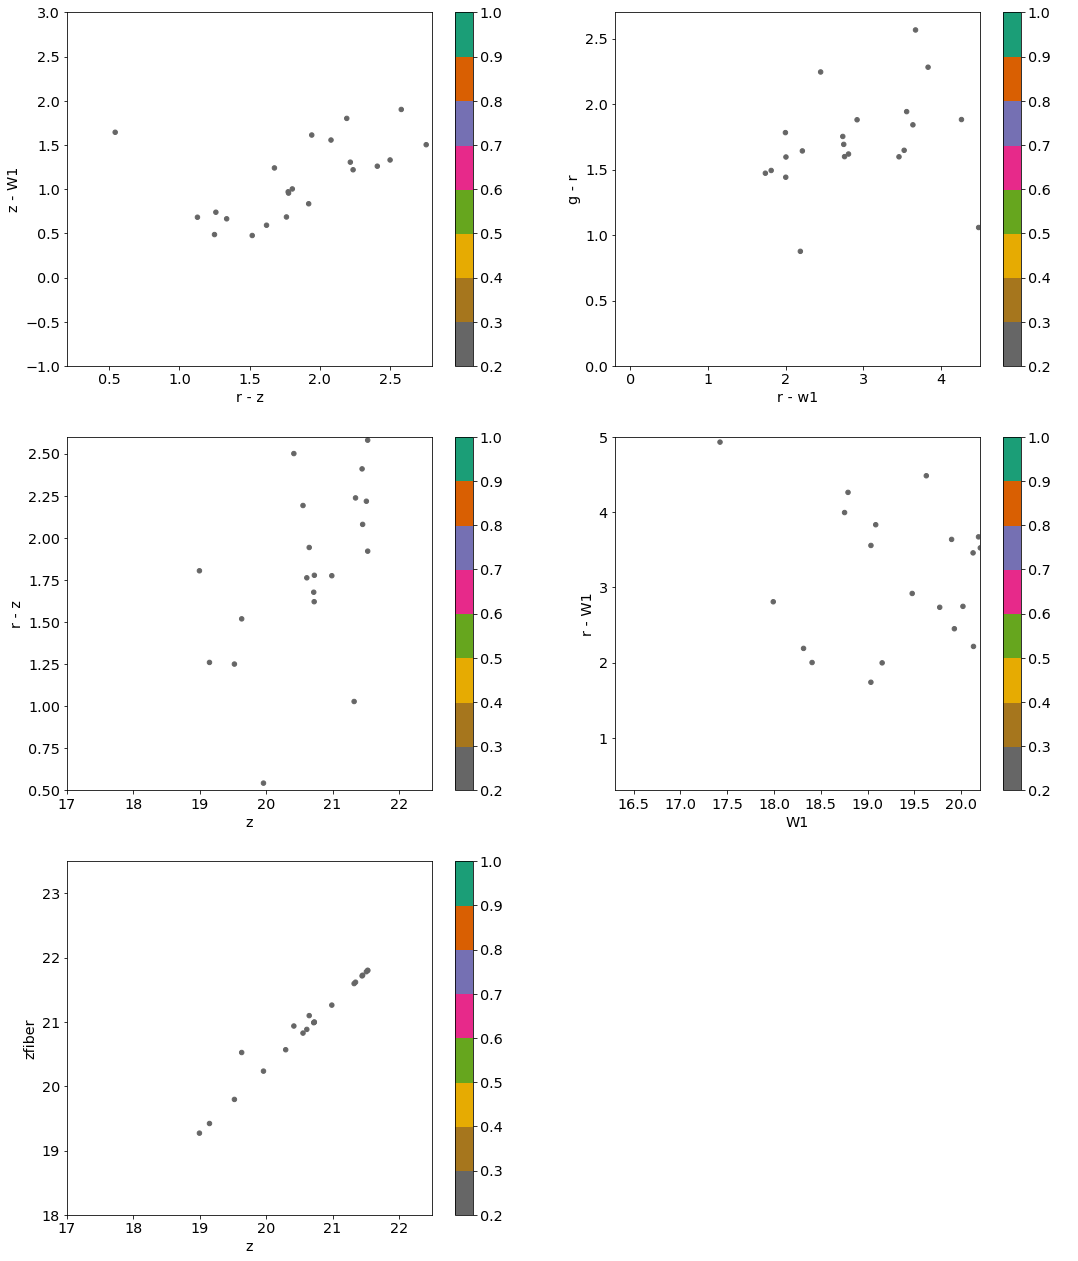

In [30]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

In [31]:
mask = lrg_opt & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKID,BRICK_OBJID,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,BRICKNAME,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39633435068730000,16480.709426522786,-114.45672902043339 .. 0.0,-0.00047406616715771485,1.0262147181202146e-05,0,7741,STAR,M,5,1848.4328474620634,0,0,0,91,91,271,0,144.4091018738411,64.24995447735166,0.0,0.0,2020.9651,5400.0,140737492418685,1,TGT,-43.053604,-184.01357,3400,0.5508891460871399,1,9011,628938,2704,DEV,0.15372582,0.9199029,5.505308,327.47784,186.83337,65.63282,0,,0.0,0.0,0.0,0.0,1442p642,0.040984172,24.32144,28.964201,0.101589315,0.6079155,3.638169,0.101589315,0.6079155,3.638169,0,4.0,0.24704072,0.307592,0.059375327,N,3400,1,140737492418685,0,0,0,0,0,2,-43.077,-183.993,-0.00044444444444444447,-0.0014444444444444446,0.0,0.0,9,0.004666666666666666,0.0061010017392410425,271,271,1,24.533133,22.590645,20.648046,19.035027,18.845346,0.35946965,0.07952996,0.022421146,23.040392,21.097794,-0.00047406616715771485
39633447978797984,70038.69661471569,418.1495006944452 .. 0.0,-0.00014749294804448397,4.603488957030019e-06,0,7731,STAR,K,5,8414.212515946987,0,0,5,43,5043,2636,0,144.0551178786656,65.48000292072304,0.0,0.0,2020.9651,5400.0,149533585449085,1,TGT,-5.931285,117.04788,3400,0.9278787250167998,1,9011,632016,2976,PSF,0.025026852,0.79691106,6.0002713,550.3564,147.61838,78.49318,0,,0.0,0.0,0.0,0.0,1438p655,0.1980728,31.522419,42.939865,0.019491052,0.6206387,4.673045,1.0643418,5.4954996,20.905722,0,0.0,0.0,0.0,0.0,N,3400,1,149533585449085,0,0,0,0,0,2,-5.945,117.013,0.001,0.00022222222222222242,0.0,0.0,9,0.0060827625302982205,0.004618802153517006,2636,2636,1,26.503984,22.746475,20.554573,18.75345,18.417849,1.7032241,0.10328087,0.018811056,23.017902,20.826,-0.00014749294804448397
39633442903688881,19499.932403963467,-630.2869141221194 .. 0.0,-6.998134541012762e-05,2.9119566061907605e-06,0,7759,STAR,M,5,19967.741326290707,0,0,7,176,7176,3536,0,146.168554661698,65.02620879609128,6.0683055,-0.965821,2020.9651,5400.0,3932281,1,TGT,-225.54514,9.6460085,3200,0.9019596620388548,1,9011,630806,1713,PSF,1.0784199,4.7894144,25.234236,399.83603,157.01207,98.934204,1064777235116362496,G2,20.537981,21.240005,19.104706,1.7931019,1461p650,0.103743054,63.56559,35.003757,0.8371354,3.7178357,19.588352,0.8371395,3.717844,19.588352,2048,0.0,0.0,0.0,0.0,N,3200,1,3932281,0,0,0,0,0,2,-225.503,9.631,-0.0030000000000000005,-0.001333333333333333,0.0,0.0,7,0.005044248650140518,0.004921607686744467,3536,3536,1,22.41803,20.799294,18.995026,

In [32]:
mask = lrg_opt & mask_zwarn
mask &= zbest['MASKBITS'] & 2**8>0
print(np.sum(mask))
zbest[mask]

13


TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKID,BRICK_OBJID,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,BRICKNAME,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39633437677585908,14329.200087487698,154.13989006539376 .. -3.1958215384913156,1.0401186160798483,6.2127190299389e-05,0,7737,GALAXY,,10,2191.9509497098625,0,0,2,381,2381,1233,0,141.06522498004364,64.41667067882638,0.0,0.0,2020.9651,5400.0,3932281,1,TGT,318.18472,-137.99196,3200,0.6858224487521225,1,9011,629560,1524,REX,0.17088465,0.8290163,5.5591645,781.8142,200.02228,67.01083,0,,0.0,0.0,0.0,0.0,1410p645,0.061703194,23.479475,19.455656,0.11472707,0.5565779,3.7322645,0.11472707,0.5565779,3.7322645,256,1.0,0.26867673,0.0,0.0,N,3200,1,3932281,0,0,0,0,0,2,318.147,-137.935,0.0057777777777777775,-0.0025555555555555557,0.0,0.0,9,0.009067647005823628,0.008582928793055822,1233,1233,1,24.418242,22.703592,20.637476,19.073278,19.277386,0.2092884,0.085289925,0.021974448,23.136185,21.070068,1.0401186160798483
39633437681778935,15715.532306149602,189.18519710482445 .. 12.274493131545677,0.2573911493862521,2.3118247604511612e-05,0,7738,GALAXY,,10,4014.740632675588,0,0,2,284,2284,1346,0,141.38899508912854,64.5759293543846,0.0,0.0,2020.9651,5400.0,1152921504610254953,1,TGT,279.0543,-98.89556,3200,0.675575677871561,7,9011,629561,247,SER,2.801754,12.262477,31.167587,290.47958,59.570232,32.964115,0,,0.0,0.0,0.0,0.0,1416p645,0.065752305,63.006954,44.72866,1.0164244,4.4485993,11.307023,1.0164244,4.4485993,11.307023,2312,1.7502413,1.2937582,0.07287887,-0.60858554,N,3200,1,1152921504610254953,257,0,0,0,0,2,279.035,-98.858,0.0006666666666666666,0.0006666666666666665,0.0,0.0,9,0.005099019513592784,0.005637178175095921,1346,1346,1,21.381424,19.778555,18.765743,18.00153,18.373535,0.020941714,0.010565916,0.005588254,20.879442,19.866629,0.2573911493862521
39633445432853870,11152.082020372152,160.17936210640448 .. 5.640861479326888,0.8504580991521087,7.117041614152725e-05,0,7736,GALAXY,,10,596.1500593349338,0,0,3,119,3119,1842,0,142.23412106764567,65.25708667510409,0.0,0.0,2020.9651,5400.0,3932281,1,TGT,181.19125,66.18324,3200,0.18308810329641434,1,9011,631409,1390,REX,0.23628585,1.0336127,7.7922864,461.09573,150.98204,50.02893,0,,0.0,0.0,0.0,0.0,1422p652,0.07201916,53.292835,32.374626,0.12325949,0.5391884,4.0648785,0.12325949,0.5391884,4.0648785,2304,1.0,0.48549247,0.0,0.0,N,3200,1,3932281,0,0,0,0,0,2,181.176,66.18,-0.0016666666666666666,0.0031111111111111114,0.0,0.0,3,0.006385748020222672,0.0066499791144200016,1842,1842,1,24.066406,22.464

----------
# Delta-chi-square

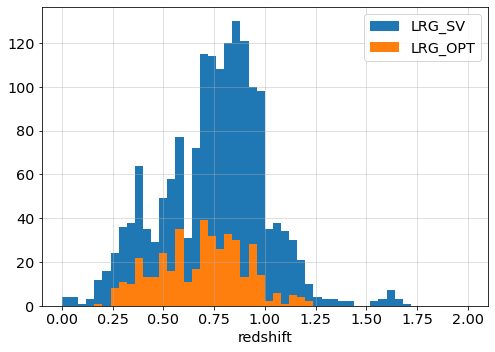

In [33]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['Z'][lrg_sv & mask_zwarn],  50, range=(0, 2.), label='LRG_SV')
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], 50, range=(0, 2.), label='LRG_OPT')
plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

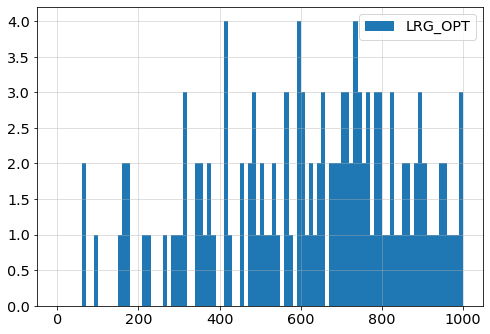

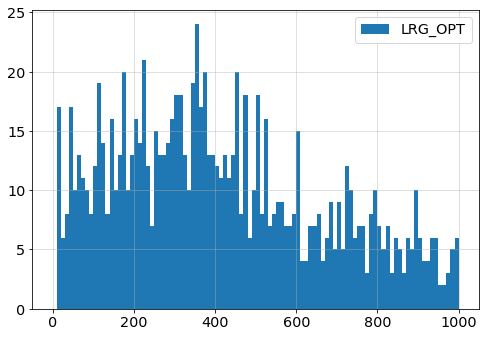

In [34]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

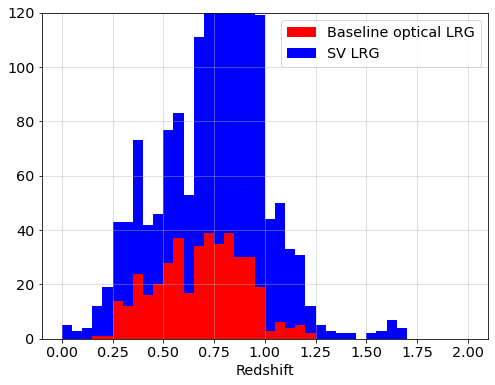

In [35]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)
plt.show()

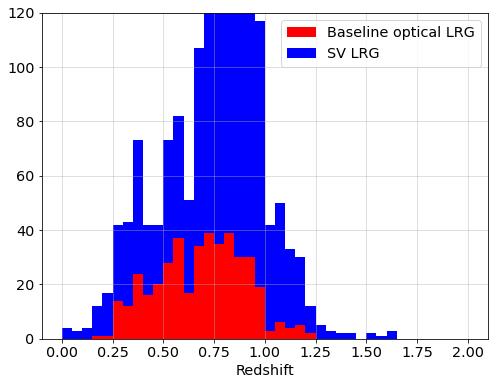

In [36]:
mask_dchi2 = zbest['DELTACHI2']>50

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)

plt.show()

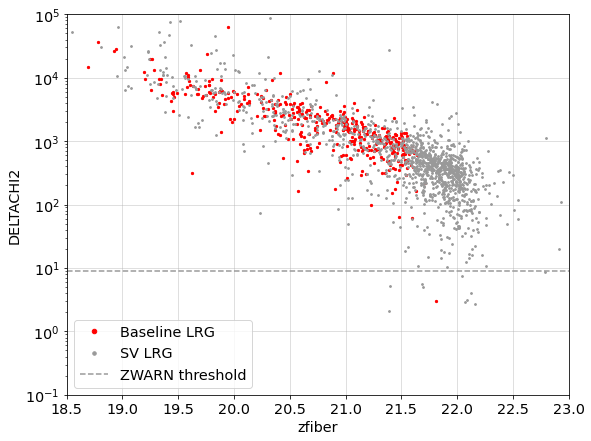

In [37]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

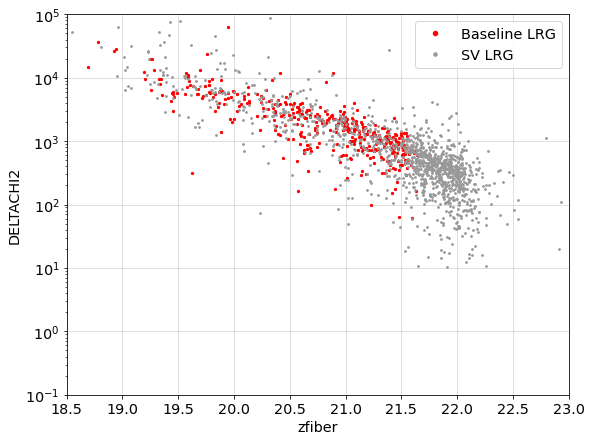

In [38]:
# Add ZWARN cut
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt & mask_zwarn], zbest['DELTACHI2'][lrg_opt & mask_zwarn], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv & mask_zwarn], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv & mask_zwarn], 'b.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

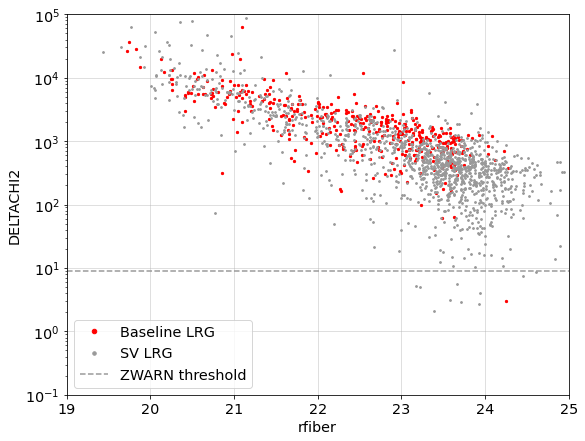

In [39]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['rfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['rfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('rfiber')
plt.ylabel('DELTACHI2')
plt.axis([19, 25, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

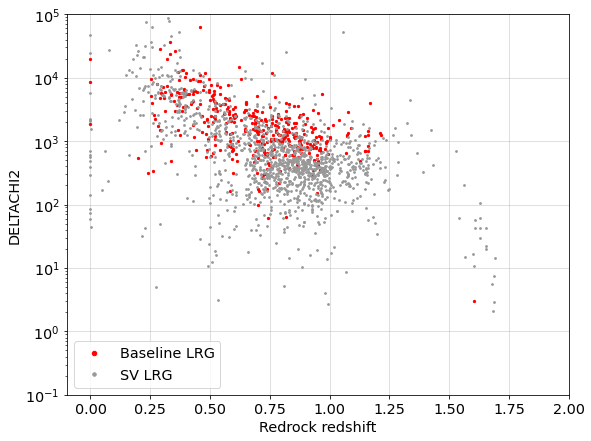

In [40]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['Z'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['Z'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('Redrock redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()